In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('../../datasets/placement_SLR.csv')
df.shape

(200, 2)

In [3]:
df.head()

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


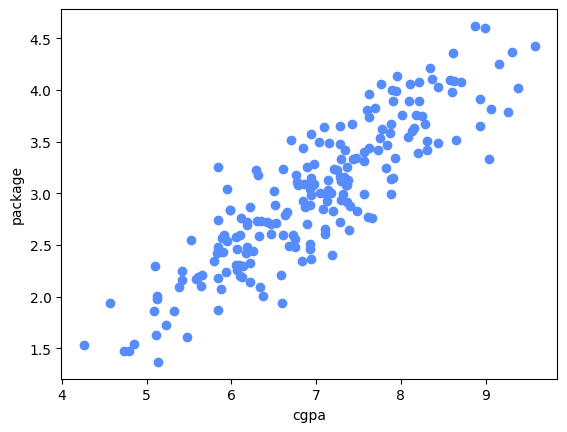

In [4]:
plt.scatter(df['cgpa'], df['package'])
plt.xlabel('cgpa')
plt.ylabel('package')
plt.show()

In [5]:
x = df.iloc[:,:1]
y = df.iloc[:,1:2]

In [6]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 0)

In [7]:
X_train


,cgpa
134,7.20
66,5.11
26,8.31
113,6.94
168,8.65
...,...
67,6.51
192,8.25
117,7.12
47,5.84


In [8]:
from sklearn.linear_model import LinearRegression

In [9]:
regressor = LinearRegression()
regressor.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [10]:
X_test

,cgpa
18,6.94
170,6.22
107,6.33
98,7.69
177,7.09
182,5.88
5,7.89
146,6.07
12,8.94
152,7.37


In [11]:
y_test

,package
18,2.98
170,2.87
107,2.59
98,3.83
177,3.64
182,2.08
5,2.99
146,2.46
12,3.65
152,3.08


In [12]:
regressor.predict(X_test.iloc[4].values.reshape(-1,1))


C:\Users\manoj\PycharmProjects\Machine-Learning\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([[3.05657563]])

In [13]:
print(regressor.coef_)
print(regressor.intercept_)

[[0.57633042]]
[-1.02960704]


In [14]:
y_pred = regressor.predict(X_test)

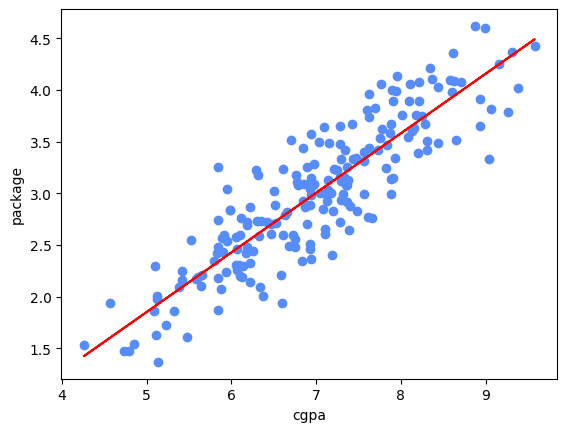

In [15]:
plt.scatter(df['cgpa'], df['package'])
# plt.plot(X_test, y_pred, color = 'red')
plt.plot(X_train, regressor.predict(X_train), color = 'red')
plt.xlabel('cgpa')
plt.ylabel('package')
plt.show()


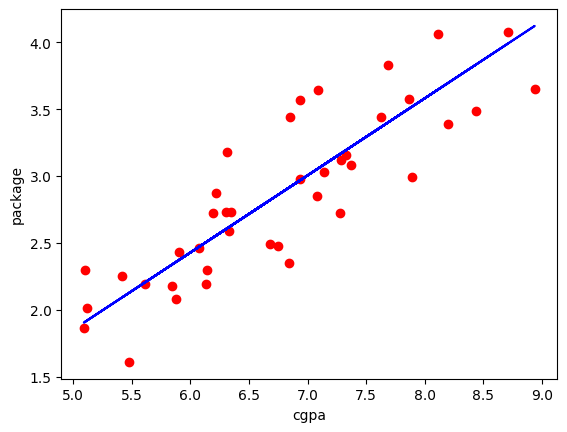

In [16]:
plt.scatter(X_test, y_test, color = 'red')
plt.plot(X_test, y_pred, color = 'blue')
plt.xlabel('cgpa')
plt.ylabel('package')
plt.show()


# Mathematical intuition

In [17]:
"""
y = mx + b
"""

'\ny = mx + b\n'

In [18]:
m = regressor.coef_[0][0]
b = regressor.intercept_[0]

In [19]:
m, b

(0.5763304184634163, -1.0296070415163103)

In [20]:
x = 6.94

y = m*x + b


In [21]:
print(f'For a CGPA of {x}, the predicted package is {y}')
print(f'For a CGPA of {x}, the predicted package is {regressor.predict([[6.94]])}')

For a CGPA of 6.94, the predicted package is 2.9701260626197987
For a CGPA of 6.94, the predicted package is [[2.97012606]]


C:\Users\manoj\PycharmProjects\Machine-Learning\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [22]:
x = 6.22
y = m*x + b

print(f'For a CGPA of {x}, the predicted package is {y}')
print(f'For a CGPA of {x}, the predicted package is {regressor.predict([[6.22]])}')

For a CGPA of 6.22, the predicted package is 2.5551681613261388
For a CGPA of 6.22, the predicted package is [[2.55516816]]


C:\Users\manoj\PycharmProjects\Machine-Learning\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [23]:
x = 7.69
y = m*x + b

print(f'For a CGPA of {x}, the predicted package is {y}')
print(f'For a CGPA of {x}, the predicted package is {regressor.predict([[7.69]])}')


For a CGPA of 7.69, the predicted package is 3.4023738764673612
For a CGPA of 7.69, the predicted package is [[3.40237388]]


C:\Users\manoj\PycharmProjects\Machine-Learning\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
